In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.datasets import load_iris
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('target', axis=1))
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['feature1', 'feature2', 'feature3'])
df_pca['target'] = df['target']
fig = px.scatter_3d(
    df_pca,
    x='feature1',
    y='feature2',
    z='feature3',
    color=df_pca['target'].astype(str)
)
fig.update_traces(
    marker=dict(size=6),
    selector=dict(mode='markers')
)

fig.show()

In [2]:
# step 1: apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [3]:
covariance_matrix = np.cov([df.iloc[:,1], df.iloc[:,2]])
print('covariance matrix:\n', covariance_matrix)

covariance matrix:
 [[ 1.00671141 -0.43131554]
 [-0.43131554  1.00671141]]


In [4]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
eigen_values

array([1.43802695, 0.57539587])

In [5]:
eigen_vectors

array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]])

TypeError: FancyArrowPatch.__init__() takes from 1 to 3 positional arguments but 4 positional arguments (and 2 keyword-only arguments) were given

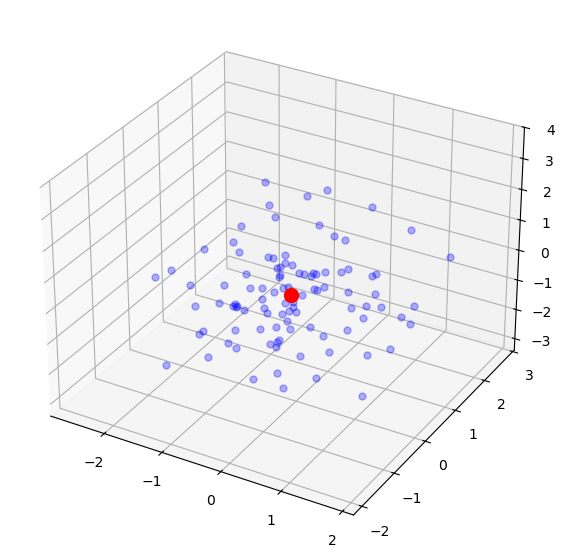

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# Custom class to draw 3D arrows (Eigenvectors)
class Arrow3D(FancyArrowPatch):
    def _init_(self, xs, ys, zs, *args, **kwargs):
        super()._init_((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

# -------------------------
# Sample dataset (3 features)
# -------------------------
np.random.seed(42)
df = pd.DataFrame({
    'feature1': np.random.randn(100),
    'feature2': np.random.randn(100),
    'feature3': np.random.randn(100)
})

# -------------------------
# Mean center data
# -------------------------
X = df - df.mean()

# -------------------------
# Covariance matrix
# -------------------------
cov_matrix = np.cov(X.T)

# -------------------------
# Eigen decomposition
# -------------------------
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# -------------------------
# 3D Plot
# -------------------------
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.plot(df['feature1'], df['feature2'], df['feature3'],
        'o', markersize=5, color='blue', alpha=0.3)

# Mean point
mean = df.mean()
ax.plot([mean['feature1']], [mean['feature2']], [mean['feature3']],
        'o', markersize=10, color='red')

# Eigenvec
mean = df.mean()

#for v in eigen_vectors.T:
    arrow = Arrow3D(
        [float(mean['feature1']), float(mean['feature1'] + v[0])],
        [float(mean['feature2']), float(mean['feature2'] + v[1])],
        [float(mean['feature3']), float(mean['feature3'] + v[2])],
        mutation_scale=20, lw=2, arrowstyle="-|>", color="green"
    )
# Labels
ax.set_xlabel('X values')
ax.set_ylabel('Y values')
ax.set_zlabel('Z values')

plt.title('PCA Eigenvectors (3D)')
plt.show()